# Example: Kaggle Ames House Prices Tabular Baseline

This example demonstrates how to build a leak-free tabular regression baseline for Kaggle House Prices using `ColumnTransformerScratch` and `ClosedFormLinearRegression`, accompanied by a diagnostic prediction fit plot.

Fitted Baseline R2: 0.8427
Fitted RMSE (log scale): 0.1584


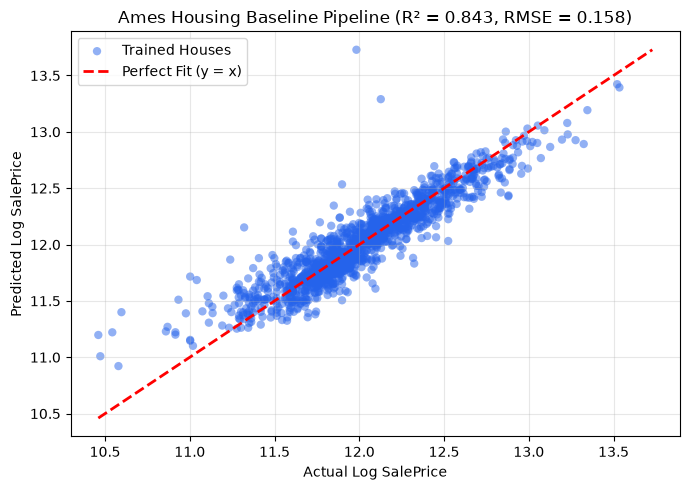

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.pipeline import PipelineScratch, ColumnTransformerScratch, StandardScalerScratch, SimpleImputerScratch, OneHotEncoderScratch
from src.solvers import ClosedFormLinearRegression
from src.linear_regression import compute_r2, compute_mse

# Load real dataset
df = pd.read_csv(root_dir / "data" / "house_prices" / "train.csv")
num_cols = ["OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars"]
cat_cols = ["Neighborhood"]

X = df[num_cols + cat_cols]
y = np.log1p(df["SalePrice"].values)

# Pipeline
preprocessor = ColumnTransformerScratch([
    ("num", PipelineScratch([("imp", SimpleImputerScratch(strategy="median")), ("scaler", StandardScalerScratch())]), num_cols),
    ("cat", PipelineScratch([("imp", SimpleImputerScratch(strategy="most_frequent")), ("ohe", OneHotEncoderScratch(handle_unknown="ignore"))]), cat_cols)
])

pipe = PipelineScratch([("prep", preprocessor), ("reg", ClosedFormLinearRegression(method="svd"))])
pipe.fit(X, y)
y_pred = pipe.predict(X)

r2 = compute_r2(y, y_pred)
rmse = np.sqrt(compute_mse(y, y_pred))
print(f"Fitted Baseline R2: {r2:.4f}")
print(f"Fitted RMSE (log scale): {rmse:.4f}")

# Diagnostic scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(y, y_pred, alpha=0.5, edgecolors='none', color='#2563eb', label='Trained Houses')
min_val, max_val = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit (y = x)')
plt.xlabel("Actual Log SalePrice")
plt.ylabel("Predicted Log SalePrice")
plt.title(f"Ames Housing Baseline Pipeline (R² = {r2:.3f}, RMSE = {rmse:.3f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What You Learned
- How to handle mixed numeric and categorical data using pure-NumPy `ColumnTransformerScratch`.
- Log-transforming skewed targets for stabilized variance and linear relationships.
- Inspecting prediction accuracy visually against the identity reference line.